  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   261  100   261    0     0    379      0 --:--:-- --:--:-- --:--:--   379
100  7312  100  7312    0     0   5243      0  0:00:01  0:00:01 --:--:-- 15524
preview:
    admit         gre       gpa  rank
0    0.0  396.189233  2.893655   2.0
1    0.0  585.598888  4.043465   3.0
2    0.0  638.498908  2.486556   2.0
3    0.0  553.889550  2.527439   1.0
4    0.0  671.671124  3.314943   4.0

info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   400 non-null    float32
 1   gre     400 non-null    float64
 2   gpa     400 non-null    float64
 3   rank    400 non-null    float32
dtypes: float32(2), float64(2)
memory usage: 9.5 KB

null values:
 admit    0
gre      0
gpa      0
rank     0
dtype: i

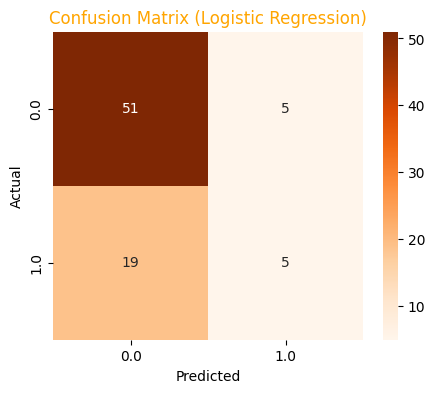

In [1]:
# download dataset
!curl -L -o ./binary.dta https://stats.idre.ucla.edu/stat/stata/dae/binary.dta

# imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

# load dataset
df = pd.read_stata('binary.dta')


df = df.sample(frac=1).reset_index(drop=True)
for col in ["gre","gpa"]:
    df[col] = df[col] * np.random.uniform(0.96,1.04,len(df)) + np.random.normal(0,1,len(df))

print("preview:\n", df.head())
print("\ninfo:")
df.info()
print("\nnull values:\n", df.isnull().sum())

# features & target
feature_columns = ["gre", "gpa", "rank"]
X = df[feature_columns]
y = df.admit

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)
print("Shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# train logistic regression
model = LogisticRegression(max_iter=1000, solver="lbfgs")
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# metrics
acc = metrics.accuracy_score(y_test, y_pred)
print("\nConfusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred))
print(f"Accuracy: {acc:.4f} ({int(acc*100)}%)")

# heatmap confusion matrix
conf_mat = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
plt.figure(figsize=(5,4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix (Logistic Regression)", color="orange")
plt.show()
